DSC550-T302<br>
Week 2 Assignment<br>
Jeremy Barton

#### Introduction

This notebook will use aviation data to make three visualizations or plots. The data is accessed via a SQLite database for reproducibility purposes. It mimics data collected from the OpenSky API which provides real-time flight data and can be used to track aircraft.

There are several uses for this type of data which include but are not limited to:

- Air Traffic Management
- Anomaly detection
- Aviation research
- Security and surveillance

#### Question

For the purpose of this exercise we would like to know, <b>what are the most common speeds among the 60 aircraft and are there any suspected anomalies? (> 500 knots)</b>

This is what each of the three graphs will answer. For decorative purposes a greenscale will be used as it might appear in a cockpit of an aircraft.

#### Imports & Preprocessing

The data will come from a SQLite database, so the `sqlite3` package is required.`pandas`, `matplotlib` and `numpy` are also required.

In [1]:
# import required packages
import sqlite3
import os
import math
import pandas as pd

# required matplotlib
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import numpy as np

#### Visualization

To paint the graphs, `rcParams` is accessed. It a global matplotlib package to matplotlib package that allows for customization of graphs based on settings stored in a dictionary-like variable called `matplotlib.rcParams`. 

The matplotlib `rcParams` settings for this graph design is as follows:

`'font.family: monospace'`<br>
`    'font.size':        9`,<br>
`    'axes.facecolor':   'black'`,<br>
`    'figure.facecolor': 'black'`,<br>
`    'text.color':       '#00FF00'`,<br>
`    'axes.labelcolor':  '#00FF00'`,<br>
`    'xtick.color':      '#00FF00'`,<br>
`    'ytick.color':      '#00FF00'`,<br>
`    'axes.edgecolor':   '#00FF00'`,<br>
`    'grid.color':       '#003300'`,<br>
`    'lines.color':      '#00FF00'`,<br>
`    'lines.linewidth':  1`,<br>
`    'axes.titlesize':   11`,<br>
`    'axes.titleweight': '500'`<br>


In [2]:
# a cockpit theme
plt.style.use('dark_background')
mpl.rcParams.update({
    'font.family':      'monospace', # monospace is a classic
    'font.size':        9,
    'axes.facecolor':   'black',
    'figure.facecolor': 'black',
    'text.color':       '#00FF00',
    'axes.labelcolor':  '#00FF00',
    'xtick.color':      '#00FF00',
    'ytick.color':      '#00FF00',
    'axes.edgecolor':   '#00FF00',
    'grid.color':       '#003300',
    'lines.color':      '#00FF00',
    'lines.linewidth':  1,
    'axes.titlesize':   11,
    'axes.titleweight': '500',
})

#### Database Loading

Accesssing the the OpenSky API data from a stored database using SQLite.

Live data can be found on the <a href="opensky-network.org/data/api"> OpenSky REST API </a> page.

In [3]:
DB_PATH = 'opensky_live.db'
assert os.path.exists(DB_PATH), f"Database not found: {DB_PATH}"

conn = sqlite3.connect(DB_PATH)

# Use the latest poll snapshot only
df = pd.read_sql('''
    SELECT *
    FROM aircraft
    WHERE fetched_at = (SELECT MAX(fetched_at) FROM aircraft)
      AND on_ground  = 0
      AND latitude   IS NOT NULL
      AND longitude  IS NOT NULL
      AND speed_kts  IS NOT NULL
      AND altitude_ft IS NOT NULL
''', conn)
conn.close()

#### Setting radar reference points

The data will simulate a location over the New York City metropolitan area. Radius will be calculated using the Haversine formula, which determines the great-circle distance between two points on a sphere given their latitude and longitude coordinates.

This type of attention to detail for the radar is important because the formula accounts for the curvature of the Earth when calculating distance, which matters at the scale of an airspace radar sweep.

In [4]:
# lattitude and longitude of radar
RADAR_LAT = 40.75 
RADAR_LON = -73.0

def haversine_nm(lat1, lon1, lat2, lon2):
    R = 3440.065  # Earth radius in nautical miles

    # degrees to radians conversion
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlam = math.radians(lon2 - lon1)

    # Haversine formula
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlam/2)**2

    # arc length -> nautical miles
    return R * 2 * math.asin(math.sqrt(a))

# making use of the .apply() function to apply the Haversine formula
# row-by-row across the dataframe, calculating each aircraft's distance 
# from the radar reference point in nautical miles
df['distance_nm'] = df.apply(
    lambda r: haversine_nm(RADAR_LAT, RADAR_LON, r['latitude'], r['longitude']),
    axis=1
)

# here, .groupby() is used to group callsign data by average speed, 
# altitude, distance, and origin country
df = df.groupby('callsign', as_index=False).agg({
    'speed_kts':   'mean',
    'altitude_ft': 'mean',
    'distance_nm': 'mean',
    'origin_country': 'first',
}).round(1) # round to the nearest tenth

print(df.columns.tolist())
print(df.head(2))

['callsign', 'speed_kts', 'altitude_ft', 'distance_nm', 'origin_country']
  callsign  speed_kts  altitude_ft  distance_nm origin_country
0  AAL4166      450.0      37725.0         63.0  United States
1  AAL7457      297.0      11420.0         39.8  United States


After printing, we can see textually that there are 60 aircraft in this snapshot.

In [5]:
print(f"Aircraft in snapshot: {len(df)}")
print(df[['callsign','speed_kts','altitude_ft','distance_nm']].head(10).to_string(index=False))

Aircraft in snapshot: 60
callsign  speed_kts  altitude_ft  distance_nm
 AAL4166      450.0      37725.0         63.0
 AAL7457      297.0      11420.0         39.8
 AAL7611      321.0      22082.0         29.3
 ACA3659      310.0      18959.0         52.0
  AFR585      494.0      29114.0         30.6
 AFR6501      472.0      29121.0         54.1
 AFR6760      504.0      38743.0         56.0
 AFR7560      461.0      28294.0         73.6
  AFR893      363.0      11439.0         67.3
 BAW5916      451.0      28137.0         43.2


#### 1) Average Speed per Aircraft

The first visualization will be average speed per aircraft. It was calculated in the previous two cells using the `mean` aggregation in `.groupby()`.

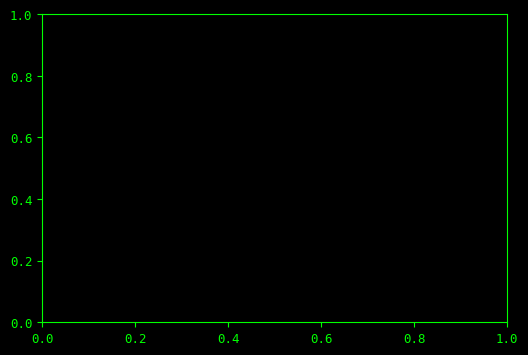

In [6]:
# size will be a 6, 4 graph
fig, spd_ax = plt.subplots(figsize=(6, 4))


Using the `nlargest()` method to pull the top 15 average aircraft speeds by `speed_kts` will prepare the data for a bar chart.

In [7]:
# get top 25 aircraft by speed
df_sorted = df.nlargest(15, 'speed_kts')
bar_colors = ['#00FF00' if s <= 500 else '#FF4444' for s in df_sorted['speed_kts']]

Now for the plot styling. `linewidth` and `linestyle` properties of `axhline` can be used to design the grid lines.

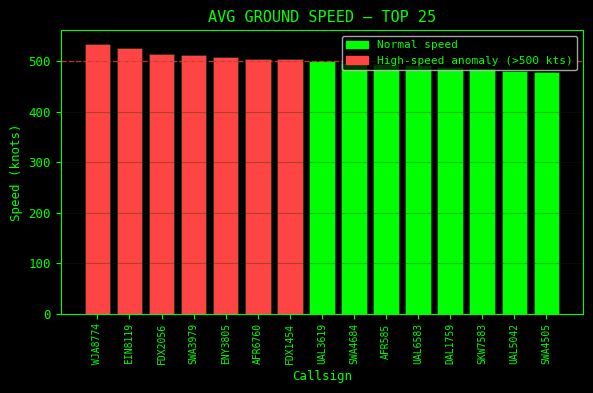

In [8]:
# creating a bar chart based on average speed
spd_ax.bar(range(len(df_sorted)), df_sorted['speed_kts'],
       color=bar_colors, edgecolor='#003300', linewidth=0.4)

# size will be a 14, 5 graph
fig, spd_ax = plt.subplots(figsize=(6, 4))

# get top 25 aircraft by speed
df_sorted = df.nlargest(15, 'speed_kts')
bar_colors = ['#00FF00' if s <= 500 else '#FF4444' for s in df_sorted['speed_kts']]

# creating a bar chart based on average speed
spd_ax.bar(range(len(df_sorted)), df_sorted['speed_kts'],
       color=bar_colors, edgecolor='#003300', linewidth=0.4)

spd_ax.axhline(500, color='#FF4444', linewidth=1, linestyle='--', alpha=0.7)
spd_ax.set_xticks(range(len(df_sorted))) # set range to length of dataset
spd_ax.set_xticklabels(df_sorted['callsign'], rotation=90, fontsize=7) # call signs on the x axis
spd_ax.set_xlabel('Callsign') # x label
spd_ax.set_ylabel('Speed (knots)') # y label
# set plot title and add grid
spd_ax.set_title('AVG GROUND SPEED — TOP 25')
spd_ax.grid(axis='y', alpha=0.3)
patches = [
    mpatches.Patch(color='#00FF00', label='Normal speed'),
    mpatches.Patch(color='#FF4444', label='High-speed anomaly (>500 kts)'),
]
spd_ax.legend(handles=patches, fontsize=8)
plt.tight_layout()
plt.show()

#### Findings

Looking at the chart, most aircraft do not exceed the 500-knot anomaly threshold. The one aircraft flagged in red may be attributable to a departure or high-speed transit through the airspace. This could be a variable worth considering in a production version of these visualizations.

#### 2) Distance from Radar Reference Point

This second plot features a scatter chart based on the snapshot data from the database. Each point represents one aircraft, positioned by its distance from the radar reference point and its altitude. The color encodes speed, directly supporting the question of where high-speed aircraft are located relative to the radar.

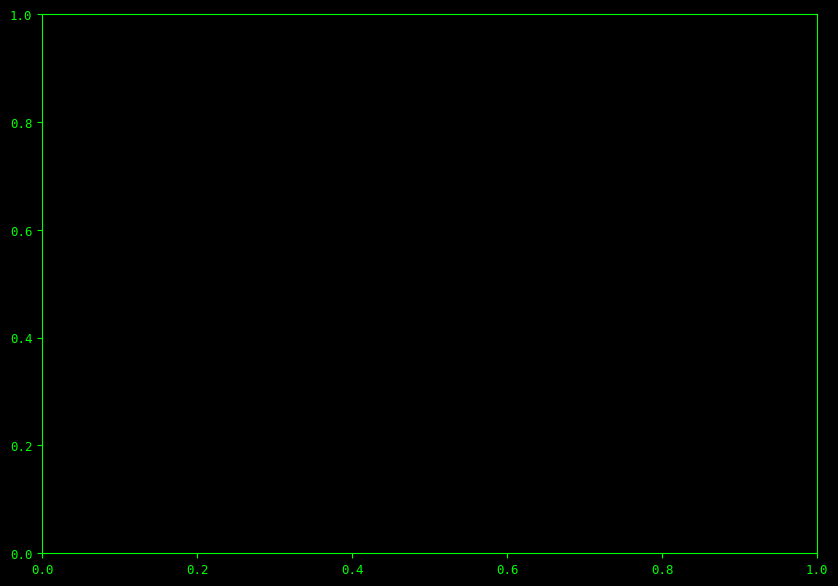

In [9]:
# size will be a 10, 7 graph
fig, ax = plt.subplots(figsize=(10, 7))

Using `.scatter()`, distance and altitude are used to plot the location of each aircraft. `cmap` and `edgecolors` set the green color scheme and `s` controls the marker size.

In [10]:
# a scatter plot with dots representing each aircraft
sc = ax.scatter(
    df['distance_nm'], df['altitude_ft'],
    c=df['speed_kts'],
    cmap='Greens',
    s=60,
    edgecolors='#004400',
    linewidth=0.4,
    alpha=0.9
)

Styling and Formatting

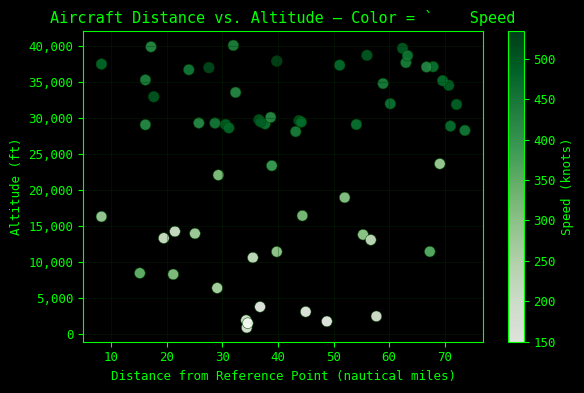

In [11]:
fig, rad_ax = plt.subplots(figsize=(6, 4))

sc = rad_ax.scatter(
    df['distance_nm'], df['altitude_ft'],
    c=df['speed_kts'],
    cmap='Greens',
    s=60,
    edgecolors='#004400',
    linewidth=0.4,
    alpha=0.9
)

# attach a colorbar to the scatter plot using the sc object
cbar = plt.colorbar(sc, ax=rad_ax)

# label the colorbar and set its color, tickmarks and labels
cbar.set_label('Speed (knots)', color='#00FF00')
cbar.ax.yaxis.set_tick_params(color='#00FF00')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#00FF00')

# x and y labels
rad_ax.set_xlabel('Distance from Reference Point (nautical miles)')
rad_ax.set_ylabel('Altitude (ft)')

# title and grid
rad_ax.set_title('Aircraft Distance vs. Altitude — Color = `    Speed')
rad_ax.grid(alpha=0.3)

# format y-axis numbers with commas (e.g. 35000 -> 35,000)
rad_ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

#### Findings

The scatter plot shows that most aircraft are concentrated between 25,000 and 40,000 feet at distances of 10 to 70 nautical miles from the reference point. Aircraft with higher speeds, indicated by lighter green, tend to cluster at cruise altitudes above 30,000 feet. No aircraft exceed the 500-knot threshold in this view.

#### 3) Speed Distribution Within Radar Radius

For the third graph the distribution of speed and distance will be plotted using `.hist()`.

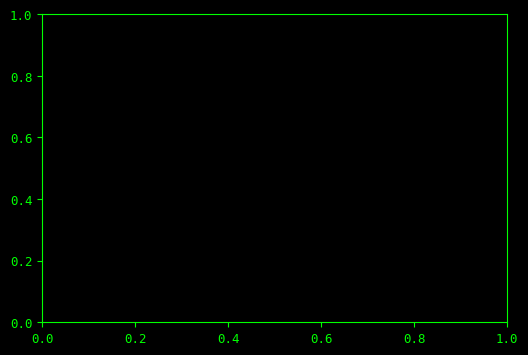

In [12]:
# same basic layout as before
RADIUS_NM = 30

df_radius = df[df['distance_nm'] <= RADIUS_NM]
df_outside = df[df['distance_nm'] > RADIUS_NM]

# fig size 10, 6
fig, ax = plt.subplots(figsize=(6, 4))

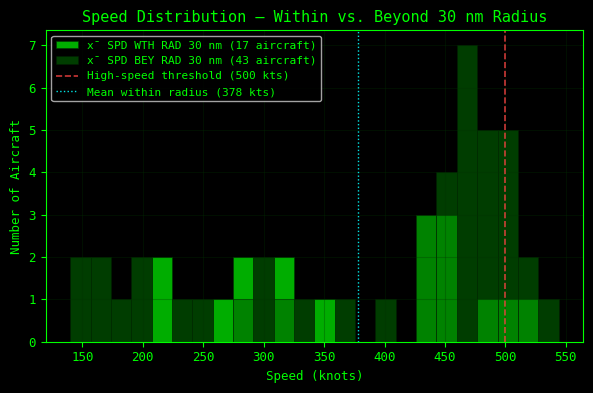

In [13]:
# same basic layout as before
RADIUS_NM = 30

df_radius = df[df['distance_nm'] <= RADIUS_NM]
df_outside = df[df['distance_nm'] > RADIUS_NM]

# fig size 10, 6
fig, ax = plt.subplots(figsize=(6, 4))

bins = np.linspace(df['speed_kts'].min() - 10, df['speed_kts'].max() + 10, 25)

# creating different colors on radius, setting alpla, color linewith and label
#       for mean speed within and beyond the radius
ax.hist(df_radius['speed_kts'],  bins=bins, color='#00CC00', alpha=0.85,
        edgecolor='#003300', linewidth=0.5, label=f'x̄ SPD WTH RAD {RADIUS_NM} nm ({len(df_radius)} aircraft)')
ax.hist(df_outside['speed_kts'], bins=bins, color='#006600', alpha=0.6,
        edgecolor='#002200', linewidth=0.5, label=f'x̄ SPD BEY RAD {RADIUS_NM} nm ({len(df_outside)} aircraft)')

# dotted line style as before
ax.axvline(500, color='#FF4444', linewidth=1.2, linestyle='--', alpha=0.8, label='High-speed threshold (500 kts)')
ax.axvline(df_radius['speed_kts'].mean(), color='#00FFFF', linewidth=1,
           linestyle=':', alpha=0.9,
           label=f'Mean within radius ({df_radius["speed_kts"].mean():.0f} kts)')

# x and y labels
ax.set_xlabel('Speed (knots)')
ax.set_ylabel('Number of Aircraft')
ax.set_title(f'Speed Distribution — Within vs. Beyond {RADIUS_NM} nm Radius')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


#### Findings

#### Findings

Looking at the distribution of speed, most aircraft fall well below the 500-knot anomaly threshold. The distribution peaks between 400 and 480 knots, which is consistent with normal cruise speeds for commercial aircraft. The mean speed within the 30-nautical-mile radius is approximately 378 knots, reflecting a mix of aircraft at various phases of flight including approach and departure.

#### Conclusion

At the beginning of the notebook we asked, <b>what are the most common speeds among the 60 aircraft and are there any suspected anomalies? (> 500 knots)</b>. The most common speeds ranged between 400 and 480 knots, consistent with normal commercial cruise and approach speeds. Only one aircraft exceeded the 500-knot threshold and was flagged as a potential anomaly. This could reasonably be attributed to the normal departure or high-speed transit pattern near JFK and EWR airports. The histogram confirms that the distribution is concentrated below the threshold, and any aircraft significantly beyond the peak of this distribution would warrant further investigation.